In [2]:
import pandas as pd

df = pd.read_csv('evo_sequence_embeddings_acc.csv')
print(f"Total number of rows: {len(df)}")

Total number of rows: 1273


In [3]:
df.head()

,id,species,0,1,2,3,4,5,6,7,...,4086,4087,4088,4089,4090,4091,4092,4093,4094,4095
0,NC_042134,Enterococcus phage,13631488.0,8585216.0,1826816.0,134144.0,708608.0,-10289152.0,503808.0,14090240.0,...,1466368.0,6094848.0,1318912.0,-32128.0,25344.0,-509952.0,28442624.0,-7602176.0,10223616.0,-11141120.0
1,NC_079184,Escherichia phage,13500416.0,8650752.0,-399360.0,473088.0,643072.0,-8323072.0,309248.0,13303808.0,...,3162112.0,4128768.0,1343488.0,-409600.0,154624.0,-618496.0,29097984.0,-9043968.0,10420224.0,-12910592.0
2,NC_079183,Escherichia phage,13631488.0,8716288.0,-405504.0,471040.0,667648.0,-8323072.0,317440.0,13369344.0,...,3129344.0,4456448.0,1368064.0,-378880.0,140288.0,-598016.0,29360128.0,-9043968.0,10551296.0,-12910592.0
3,NC_079182,Escherichia phage,12976128.0,8192000.0,301056.0,350208.0,585728.0,-9109504.0,266240.0,13500416.0,...,2506752.0,3817472.0,1245184.0,-528384.0,205824.0,-614400.0,28966912.0,-8159232.0,10485760.0,-12058624.0
4,NC_079181,Escherichia phage,13172736.0,8454144.0,-532480.0,421888.0,573440.0,-7831552.0,149504.0,12845056.0,...,3096576.0,3358720.0,1269760.0,-573440.0,144384.0,-671744.0,28311552.0,-8978432.0,9895936.0,-12779520.0


In [5]:
import torch
from tqdm import tqdm
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [26]:
!pip install umap-learn xgboost lightgbm shap

In [11]:
embedding_matrix = df.iloc[:, 2:].to_numpy()

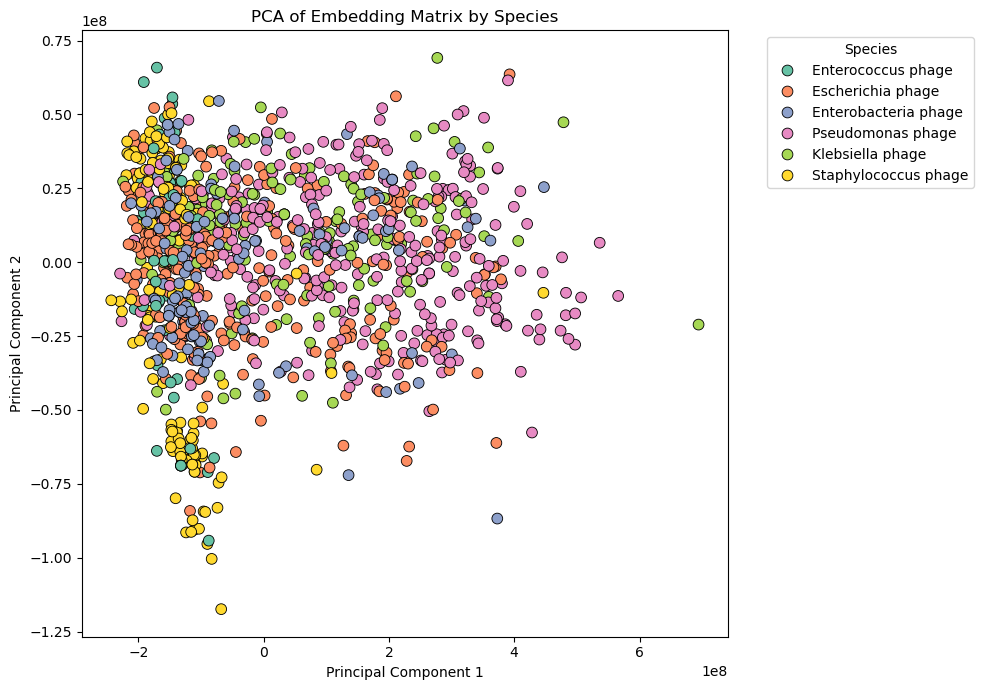

In [12]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(embedding_matrix)

pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'species': df['species']
})

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='species',
    palette='Set2',
    s=60,
    edgecolor='k'
)
plt.title('PCA of Embedding Matrix by Species')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

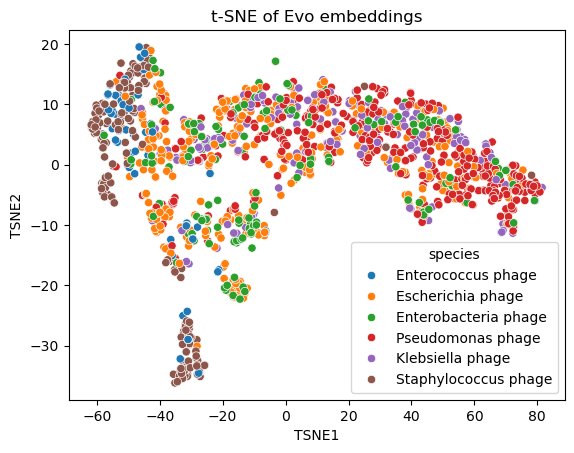

In [13]:
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(embedding_matrix)
tsne_df = pd.DataFrame({'TSNE1': X_tsne[:, 0], 'TSNE2': X_tsne[:, 1], 'species': df['species']})

sns.scatterplot(data=tsne_df, x='TSNE1', y='TSNE2', hue='species')
plt.title('t-SNE of Evo embeddings')
plt.show()

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


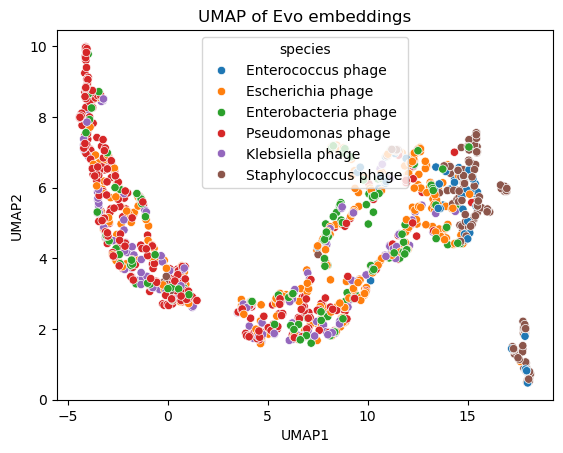

In [14]:
import umap.umap_ as umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(embedding_matrix)
umap_df = pd.DataFrame({'UMAP1': X_umap[:, 0], 'UMAP2': X_umap[:, 1], 'species': df['species']})

sns.scatterplot(data=umap_df, x='UMAP1', y='UMAP2', hue='species')
plt.title('UMAP of Evo embeddings')
plt.show()

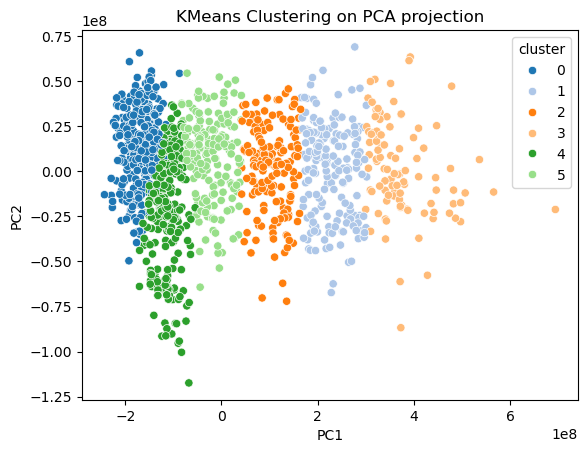

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=df['species'].nunique(), random_state=42)
clusters = kmeans.fit_predict(embedding_matrix)

df['cluster'] = clusters

pca_df['cluster'] = clusters
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='tab20')
plt.title('KMeans Clustering on PCA projection')
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test = train_test_split(
    embedding_matrix, df['species'], test_size=0.2, random_state=42
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

Enterobacteria phage       0.63      0.36      0.46        33
  Enterococcus phage       0.50      0.62      0.56         8
   Escherichia phage       0.54      0.71      0.61        66
    Klebsiella phage       0.57      0.38      0.46        34
   Pseudomonas phage       0.70      0.71      0.71        77
Staphylococcus phage       0.89      0.89      0.89        37

            accuracy                           0.65       255
           macro avg       0.64      0.61      0.61       255
        weighted avg       0.65      0.65      0.64       255



<Axes: xlabel='PC1', ylabel='PC2'>

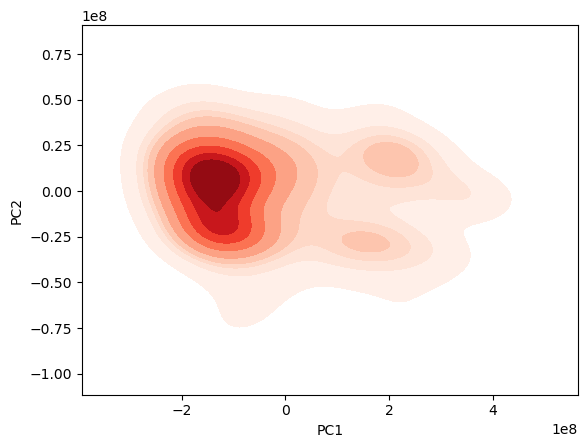

In [18]:
subset = pca_df[pca_df['species'] == 'Escherichia phage']
sns.kdeplot(data=subset, x='PC1', y='PC2', fill=True, cmap="Reds")

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import numpy as np

# 1. 标签编码
le = LabelEncoder()
y = le.fit_transform(df['species'])

# 2. 原始数据划分给 XGBoost（4096维）
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    embedding_matrix, y, test_size=0.3, random_state=42
)

# 3. 标准化 + PCA 降维（用于 LGBM / SVM / MLP）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(embedding_matrix)

pca = PCA(n_components=200)
X_pca = pca.fit_transform(X_scaled)

# 降维后划分（必须保持顺序一致）
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca, y, test_size=0.3, random_state=42)

# ================================
# A. 原始高维模型：XGBoost
# ================================
xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_clf.fit(X_train_raw, y_train)

# ================================
# B. 降维后模型：LGBM / SVM / MLP
# ================================

lgbm_clf = LGBMClassifier(random_state=42)
lgbm_clf.fit(X_train_pca, y_train)

svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train_pca, y_train)

mlp_clf = MLPClassifier(hidden_layer_sizes=(256, 64), max_iter=500, random_state=42)
mlp_clf.fit(X_train_pca, y_train)

# ================================
# Voting 集成预测（Soft Voting）
# ================================

# 各模型概率预测（注意输入维度要一致）
y_pred_xgb = xgb_clf.predict_proba(X_test_raw)
y_pred_lgbm = lgbm_clf.predict_proba(X_test_pca)
y_pred_svm = svm_clf.predict_proba(X_test_pca)
y_pred_mlp = mlp_clf.predict_proba(X_test_pca)

# Soft voting：平均概率
y_pred_proba_avg = (y_pred_xgb + y_pred_lgbm + y_pred_svm + y_pred_mlp) / 4
y_pred_ensemble = np.argmax(y_pred_proba_avg, axis=1)

# ================================
# 评估指标输出
# ================================
print(classification_report(y_test, y_pred_ensemble, target_names=le.classes_))
accuracy = accuracy_score(y_test, y_pred_ensemble)
print(f"\n✅ Voting Ensemble Accuracy: {accuracy:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003058 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 50999
[LightGBM] [Info] Number of data points in the train set: 891, number of used features: 200
[LightGBM] [Info] Start training from score -2.064957
[LightGBM] [Info] Start training from score -2.963703
[LightGBM] [Info] Start training from score -1.299283
[LightGBM] [Info] Start training from score -1.980160
[LightGBM] [Info] Start training from score -1.337023
[LightGBM] [Info] Start training from score -1.909543
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


原始 ARI 得分: 0.0629
置换检验 p 值: 0.0010


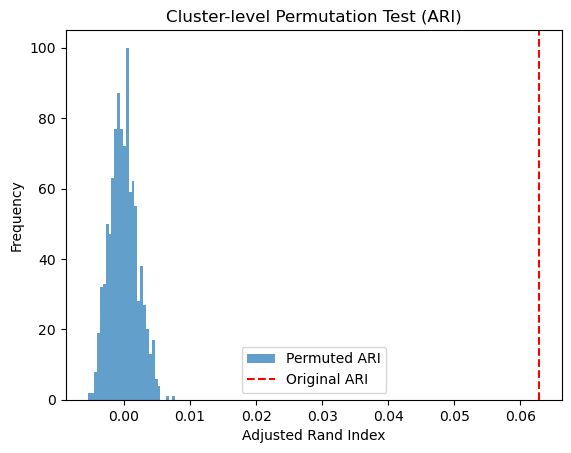

In [22]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

# Step 1: 读取数据
df = pd.read_csv('evo_sequence_embeddings_acc.csv')
embedding_matrix = df.iloc[:, 2:].to_numpy()
true_labels = df['species'].to_numpy()

# Step 2: 原始 KMeans 聚类 + 计算 ARI
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(embedding_matrix)
original_ari = adjusted_rand_score(true_labels, cluster_labels)
print(f"原始 ARI 得分: {original_ari:.4f}")

# Step 3: 置换检验
n_permutations = 1000
permuted_aris = []

for _ in range(n_permutations):
    permuted_labels = np.random.permutation(true_labels)
    ari = adjusted_rand_score(permuted_labels, cluster_labels)
    permuted_aris.append(ari)

# Step 4: 计算 p 值
permuted_aris = np.array(permuted_aris)
p_value = (np.sum(permuted_aris >= original_ari) + 1) / (n_permutations + 1)
print(f"置换检验 p 值: {p_value:.4f}")

# Step 5: 可视化
plt.hist(permuted_aris, bins=30, alpha=0.7, label='Permuted ARI')
plt.axvline(original_ari, color='red', linestyle='--', label='Original ARI')
plt.title('Cluster-level Permutation Test (ARI)')
plt.xlabel('Adjusted Rand Index')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [24]:
import pandas as pd
from sklearn.metrics import silhouette_samples
from itertools import combinations
import scipy.stats as stats
import numpy as np

labels = df['species'].to_numpy()
unique_species = np.unique(labels)

results = []

for s1, s2 in combinations(unique_species, 2):
    mask = (labels == s1) | (labels == s2)
    subset_embeddings = embedding_matrix[mask]
    subset_labels = labels[mask]

    # Encode to 0 and 1
    encoded_labels = np.array([0 if l == s1 else 1 for l in subset_labels])
    
    # silhouette score
    scores = silhouette_samples(subset_embeddings, encoded_labels)
    mean_score = np.mean(scores)

    # t test
    score_0 = scores[encoded_labels == 0]
    score_1 = scores[encoded_labels == 1]
    t_stat, p_val = stats.ttest_ind(score_0, score_1, equal_var=False)

    results.append([f"{s1} vs {s2}", round(mean_score, 4), round(t_stat, 4), round(p_val, 4)])

results_df = pd.DataFrame(results, columns=['Species Pair', 'Mean Silhouette', 'T-stat', 'P-value'])
print(results_df.sort_values(by='Mean Silhouette', ascending=False).to_string(index=False))

                                Species Pair  Mean Silhouette   T-stat  P-value
   Pseudomonas phage vs Staphylococcus phage           0.3405 -20.5568      0.0
    Klebsiella phage vs Staphylococcus phage           0.3088 -18.3857      0.0
     Enterococcus phage vs Pseudomonas phage           0.2293  23.4622      0.0
Enterobacteria phage vs Staphylococcus phage           0.1816 -25.1371      0.0
      Escherichia phage vs Pseudomonas phage           0.1566   7.9985      0.0
      Enterococcus phage vs Klebsiella phage           0.1473  20.0148      0.0
   Enterobacteria phage vs Pseudomonas phage           0.1230   7.1667      0.0
       Escherichia phage vs Klebsiella phage           0.0736   7.3360      0.0
   Escherichia phage vs Staphylococcus phage           0.0626 -34.8418      0.0
    Enterobacteria phage vs Klebsiella phage           0.0534   7.6946      0.0
       Klebsiella phage vs Pseudomonas phage           0.0333   6.3535      0.0
  Enterobacteria phage vs Enterococcus p

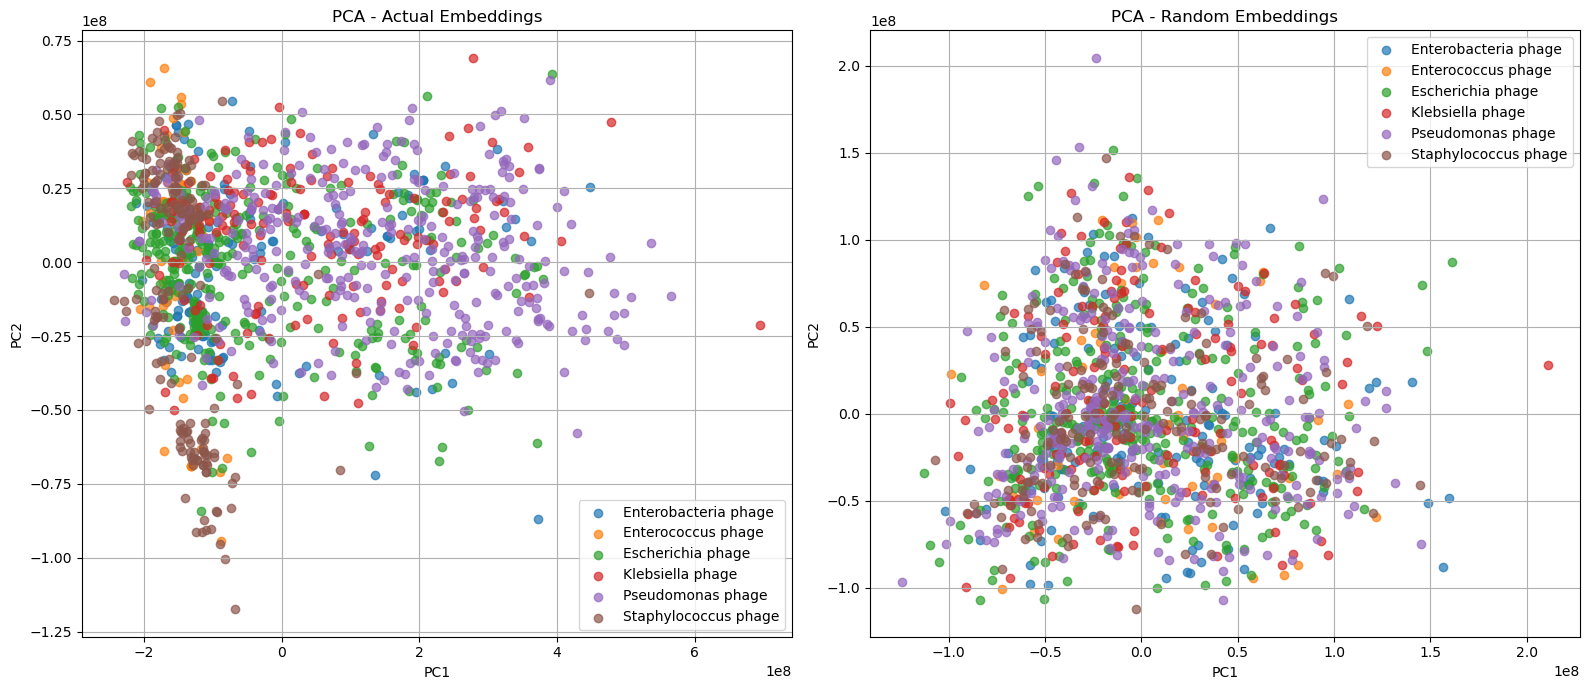

100%|██████████| 1000/1000 [00:33<00:00, 29.68it/s]


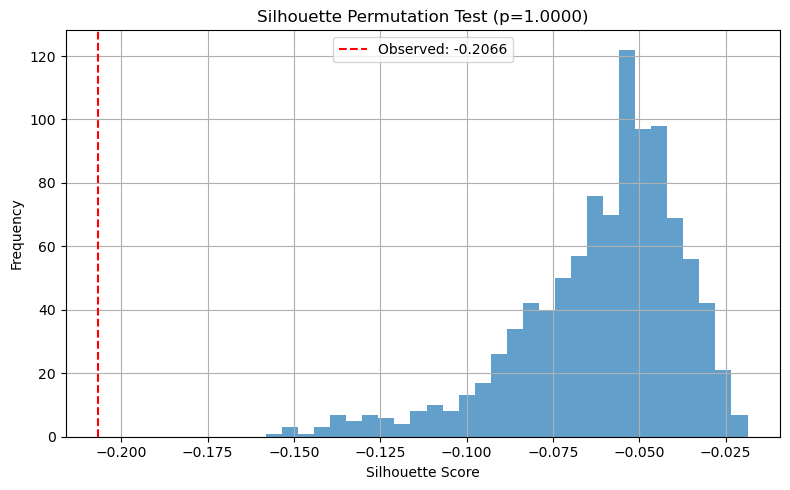

Enterobacteria phage vs Enterococcus phage: Silhouette = -0.0004, p = 0.4740
Enterobacteria phage vs Escherichia phage: Silhouette = 0.1150, p = 0.0000
Enterobacteria phage vs Klebsiella phage: Silhouette = 0.0671, p = 0.0000
Enterobacteria phage vs Pseudomonas phage: Silhouette = 0.0281, p = 0.0080
Enterobacteria phage vs Staphylococcus phage: Silhouette = 0.0342, p = 0.0000
Enterococcus phage vs Escherichia phage: Silhouette = 0.0705, p = 0.0860
Enterococcus phage vs Klebsiella phage: Silhouette = 0.0456, p = 0.0640
Enterococcus phage vs Pseudomonas phage: Silhouette = -0.0302, p = 0.7560
Enterococcus phage vs Staphylococcus phage: Silhouette = 0.0137, p = 0.2780
Escherichia phage vs Klebsiella phage: Silhouette = 0.0079, p = 0.2920
Escherichia phage vs Pseudomonas phage: Silhouette = 0.0171, p = 0.0020
Escherichia phage vs Staphylococcus phage: Silhouette = 0.0279, p = 0.0260
Klebsiella phage vs Pseudomonas phage: Silhouette = -0.0250, p = 0.9920
Klebsiella phage vs Staphylococcus p

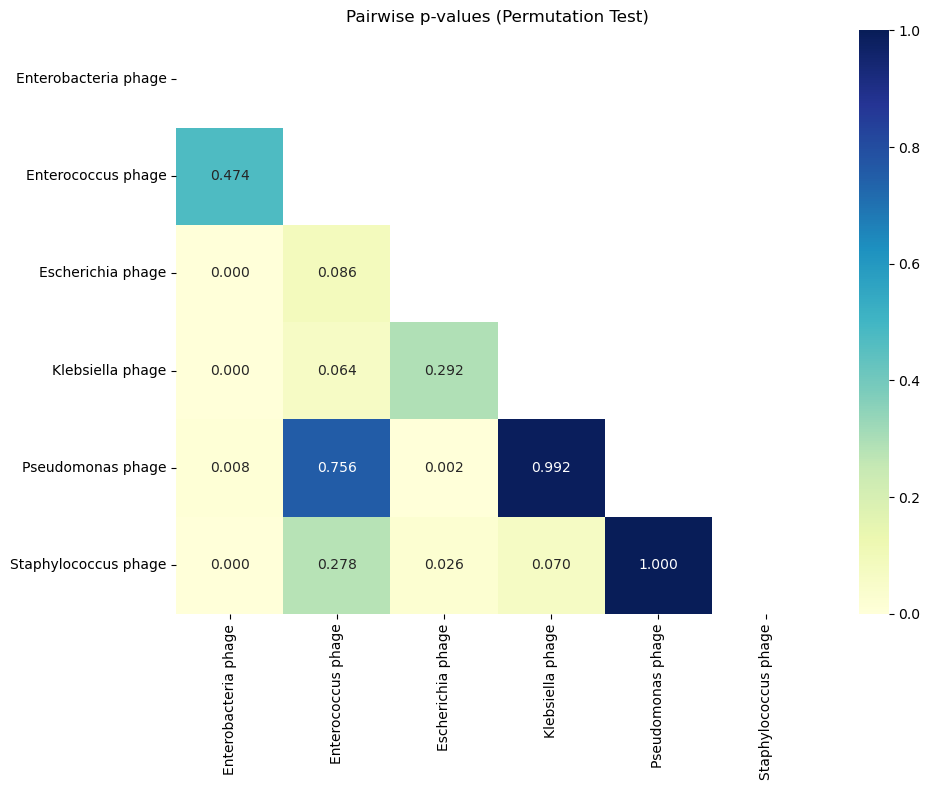

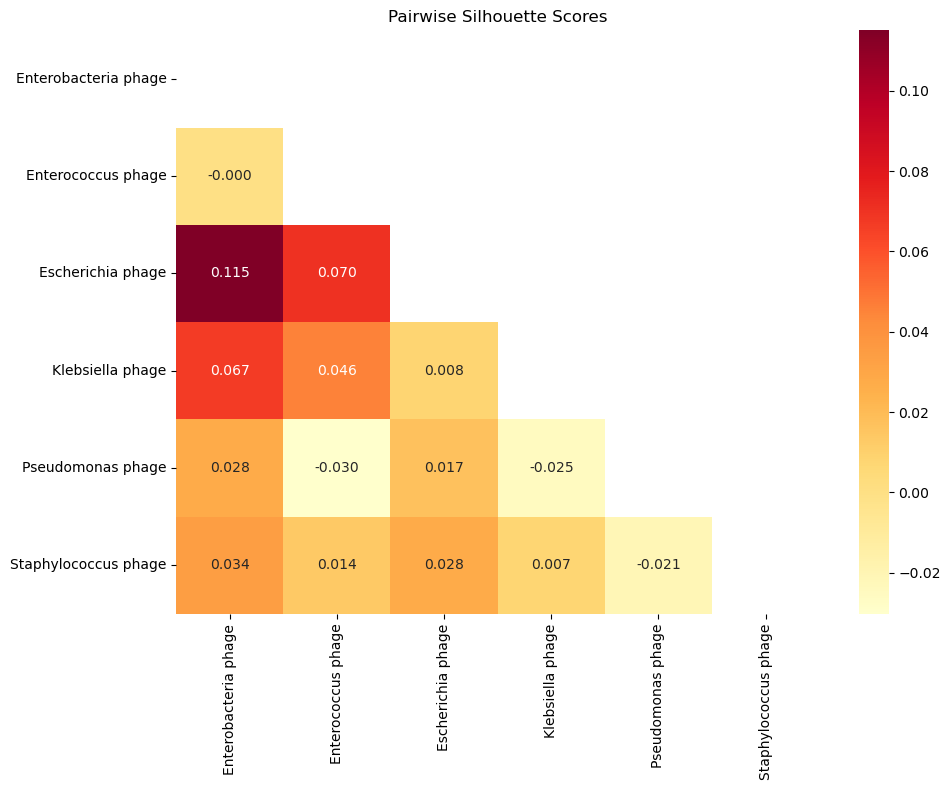


✅ 全局 silhouette = -0.2066 (p = 1.0000)
✅ 分析完成


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import os

# 1. 读取数据
df = pd.read_csv("evo_sequence_embeddings_acc.csv")
embedding_matrix = df.iloc[:, 2:].to_numpy()
labels = df['species'].values

# 建立索引字典
unique_species = np.unique(labels)
family_indices = {}
current = 0
for species in unique_species:
    count = (labels == species).sum()
    family_indices[species] = (current, current + count)
    current += count

# 编码标签
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 2. PCA 降维 + 可视化（原始 vs 随机）
pca = PCA(n_components=2)
actual_pca = pca.fit_transform(embedding_matrix)

random_embeddings = np.copy(embedding_matrix)
for j in range(random_embeddings.shape[1]):
    random_embeddings[:, j] = np.random.permutation(random_embeddings[:, j])
random_pca = PCA(n_components=2).fit_transform(random_embeddings)

plt.figure(figsize=(16, 7))

# Actual embeddings PCA
plt.subplot(1, 2, 1)
for species in unique_species:
    idx = df['species'] == species
    plt.scatter(actual_pca[idx, 0], actual_pca[idx, 1], label=species, alpha=0.7)
plt.title("PCA - Actual Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)

# Random embeddings PCA
plt.subplot(1, 2, 2)
for species in unique_species:
    idx = df['species'] == species
    plt.scatter(random_pca[idx, 0], random_pca[idx, 1], label=species, alpha=0.7)
plt.title("PCA - Random Embeddings")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("pca_actual_vs_random.png", dpi=300)
plt.show()

# 3. Silhouette + permutation test
def permutation_test(data, labels, n_permutations=1000):
    observed = silhouette_score(data, labels)
    perm_scores = []
    for _ in tqdm(range(n_permutations)):
        permuted = np.random.permutation(labels)
        score = silhouette_score(data, permuted)
        perm_scores.append(score)
    p_val = np.mean(np.array(perm_scores) >= observed)
    return observed, perm_scores, p_val

obs_sil, perm_scores, p_val = permutation_test(embedding_matrix, labels_encoded)

plt.figure(figsize=(8, 5))
plt.hist(perm_scores, bins=30, alpha=0.7)
plt.axvline(obs_sil, color='red', linestyle='--', label=f'Observed: {obs_sil:.4f}')
plt.title(f'Silhouette Permutation Test (p={p_val:.4f})')
plt.xlabel('Silhouette Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("silhouette_permutation.png", dpi=300)
plt.show()

# 4. Pairwise significance testing
from sklearn.metrics import silhouette_samples

def pairwise_silhouette_test(embedding_matrix, family_indices, n_permutations=500):
    species = list(family_indices.keys())
    n = len(species)
    p_values = np.zeros((n, n))
    silhouette_scores = np.zeros((n, n))
    
    for i in range(n):
        for j in range(i+1, n):
            s1, s2 = species[i], species[j]
            idx1 = slice(*family_indices[s1])
            idx2 = slice(*family_indices[s2])
            X1, X2 = embedding_matrix[idx1], embedding_matrix[idx2]
            X = np.vstack([X1, X2])
            y = np.array([0]*len(X1) + [1]*len(X2))
            
            obs_s = silhouette_score(X, y)
            silhouette_scores[i, j] = silhouette_scores[j, i] = obs_s
            
            perms = []
            for _ in range(n_permutations):
                yp = np.random.permutation(y)
                perms.append(silhouette_score(X, yp))
            p = np.mean(np.array(perms) >= obs_s)
            p_values[i, j] = p_values[j, i] = p
            
            print(f"{s1} vs {s2}: Silhouette = {obs_s:.4f}, p = {p:.4f}")
    
    return p_values, silhouette_scores, species

p_matrix, s_matrix, species_order = pairwise_silhouette_test(embedding_matrix, family_indices)

# 5. 可视化 Pairwise heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(p_matrix, xticklabels=species_order, yticklabels=species_order,
            cmap="YlGnBu", annot=True, fmt=".3f", mask=np.triu(np.ones_like(p_matrix, dtype=bool)))
plt.title("Pairwise p-values (Permutation Test)")
plt.tight_layout()
plt.savefig("pairwise_pvalue_heatmap.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(s_matrix, xticklabels=species_order, yticklabels=species_order,
            cmap="YlOrRd", annot=True, fmt=".3f", mask=np.triu(np.ones_like(s_matrix, dtype=bool)))
plt.title("Pairwise Silhouette Scores")
plt.tight_layout()
plt.savefig("pairwise_silhouette_heatmap.png", dpi=300)
plt.show()

print(f"\n✅ 全局 silhouette = {obs_sil:.4f} (p = {p_val:.4f})")
print("✅ 分析完成")


100%|██████████| 1000/1000 [00:32<00:00, 30.79it/s]


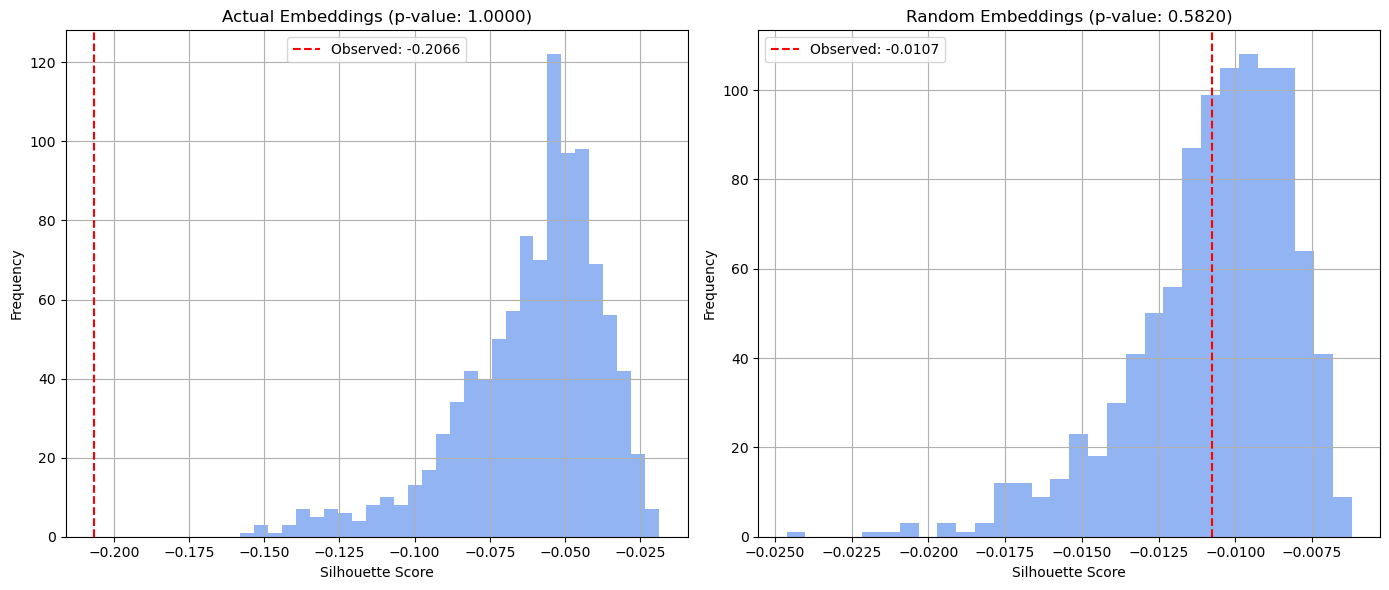


📊 双图 silhouette 分布对比已生成！文件名：actual_vs_random_dual_silhouette.png


In [35]:
# 6. 再做一次：对 random_embeddings 也进行 permutation test
random_obs_sil, random_perm_scores, random_p_val = permutation_test(random_embeddings, labels_encoded)

# 7. 生成双图对比图：实际 vs 随机 embeddings
plt.figure(figsize=(14, 6))

# 左图：Actual Embeddings
plt.subplot(1, 2, 1)
plt.hist(perm_scores, bins=30, alpha=0.7, color='cornflowerblue')
plt.axvline(obs_sil, color='red', linestyle='--', label=f'Observed: {obs_sil:.4f}')
plt.title(f'Actual Embeddings (p-value: {p_val:.4f})')
plt.xlabel('Silhouette Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

# 右图：Random Embeddings
plt.subplot(1, 2, 2)
plt.hist(random_perm_scores, bins=30, alpha=0.7, color='cornflowerblue')
plt.axvline(random_obs_sil, color='red', linestyle='--', label=f'Observed: {random_obs_sil:.4f}')
plt.title(f'Random Embeddings (p-value: {random_p_val:.4f})')
plt.xlabel('Silhouette Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("actual_vs_random_dual_silhouette.png", dpi=300)
plt.show()

print("\n📊 双图 silhouette 分布对比已生成！文件名：actual_vs_random_dual_silhouette.png")